In [79]:
from google.colab import files
uploaded = files.upload()

Saving deliveries.csv to deliveries (1).csv


In [80]:
from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches (2).csv


In [81]:
import pandas as pd
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [82]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [83]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [84]:
#matches info
print("Matches columns:")
print(matches.columns.to_list())

#deliveries info
print("Deliveries columns:")
print(deliveries.columns.to_list())

Matches columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [85]:
#Data cleanig
#finding missing values
print("Missing values in matches:")
print(matches.isnull().sum())

Missing values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [86]:
#filling missing values
matches['city'] = matches['city'].fillna('Unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('Unknown')
matches['winner'] = matches['winner'].fillna('Unknown')

#dropping duplicates
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

#checking the nulls
print("Missing values after cleaning:")
print(matches[['city','player_of_match','winner']].isnull().sum())
print("\nData cleaning done")

Missing values after cleaning:
city               0
player_of_match    0
winner             0
dtype: int64

Data cleaning done


In [87]:
# check unique values in winner column
print(matches['winner'].value_counts().head(20))

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Unknown                          5
Rising Pune Supergiants          5
Name: count, dtype: int64


In [88]:
# Check exact column names
print(matches.columns.tolist())

# Check first 5 rows
print(matches.head())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3         

In [89]:
# The first time you ran the notebook you may have run the fillna code before the data was properly loaded. Reloading the data fresh fixes everything.
# Reload data completely fresh
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Data reloaded fresh!")
print(matches['winner'].value_counts().head(5))

Data reloaded fresh!
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: count, dtype: int64


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


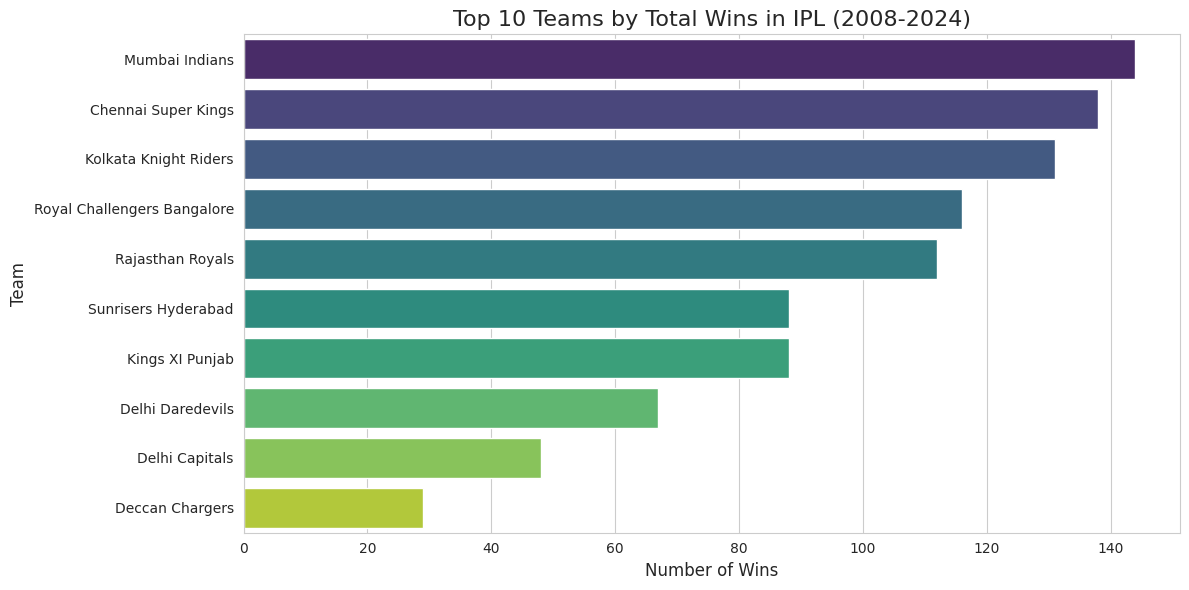

Observation: Which team has the most wins?
Answer: Mumbai Indians with 144 wins


In [91]:
#Analysis1-Top 10 teams by total wins
plt.figure(figsize=(12,6))

top_winners = matches[matches['winner'] != 'No Result']['winner'].value_counts().head(10)

sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')
plt.title('Top 10 Teams by Total Wins in IPL (2008-2024)', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.tight_layout()
plt.savefig('analysis1_top_winners.png')
plt.show()

print("Observation: Which team has the most wins?")
print(f"Answer: {top_winners.index[0]} with {top_winners.values[0]} wins")

Toss winner also win the match: 50.59%


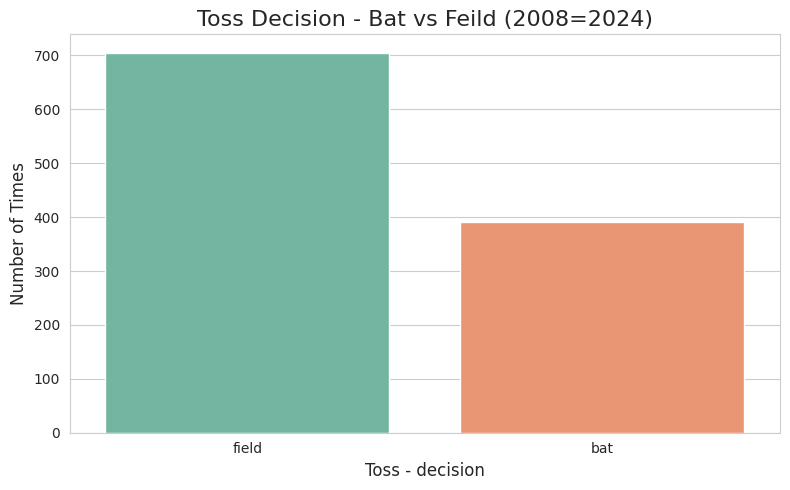

In [92]:
# Analysis2 - Toss impact
# Calculate Toss win percentage
toss_win = matches[matches['toss_winner'] == matches['winner']]
percentage = round(len(toss_win)/len(matches) * 100, 2)
print(f"Toss winner also win the match: {percentage}%")

# chart
plt.figure(figsize=(8,5))
sns.countplot(x='toss_decision', data=matches, palette='Set2')
plt.title('Toss Decision - Bat vs Feild (2008=2024)', fontsize=16)
plt.xlabel('Toss - decision', fontsize=12)
plt.ylabel('Number of Times', fontsize=12)
plt.tight_layout()
plt.savefig('analysis2_toss_impact.png')
plt.show()



Total matches: 1095
Toss winner sample: ['Royal Challengers Bangalore', 'Chennai Super Kings', 'Rajasthan Royals']
Winner column sample: ['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils']

Matches where toss winner won: 554
Toss winner also won the match: 50.59%


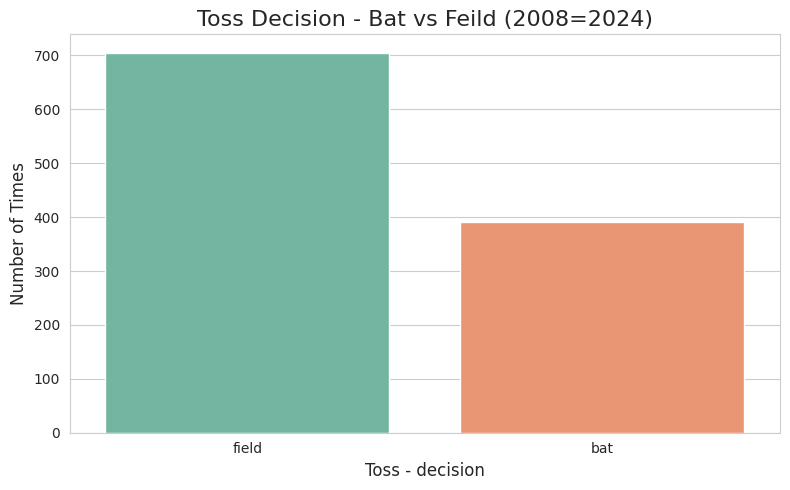

In [93]:
# check toss winner vs match winner
print('Total matches:', len(matches))
print('Toss winner sample:', matches['toss_winner'].head(3).tolist())
print("Winner column sample:", matches['winner'].head(3).tolist())

# calculate correctly
toss_win = matches[matches['toss_winner'] == matches['winner']]
percentage = round(len(toss_win)/len(matches) * 100, 2)

print(f"\nMatches where toss winner won: {len(toss_win)}")
print(f"Toss winner also won the match: {percentage}%")

# Analysis2 - Toss impact on match results

# chart
plt.figure(figsize=(8,5))
sns.countplot(x='toss_decision', data=matches, palette='Set2')
plt.title('Toss Decision - Bat vs Feild (2008=2024)', fontsize=16)
plt.xlabel('Toss - decision', fontsize=12)
plt.ylabel('Number of Times', fontsize=12)
plt.tight_layout()
plt.savefig('analysis2_toss_impact.png')
plt.show()

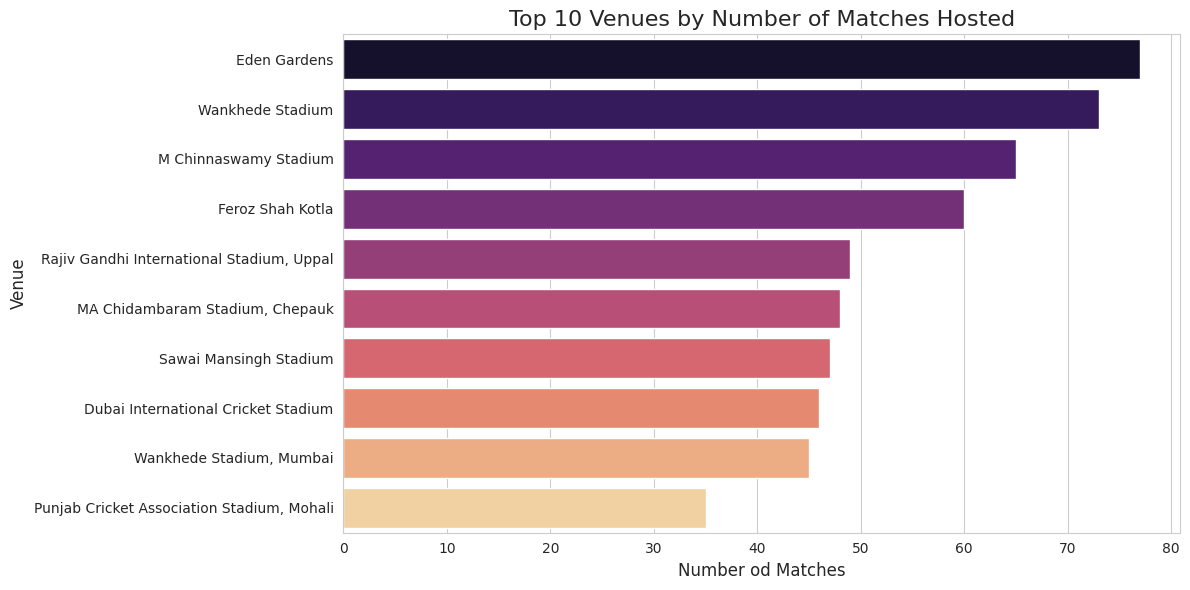

Observation: Wankede Stadium and Eden Gardens hosted the most matches


In [94]:
# Analysis3 - Top 10 Venues

plt.figure(figsize=(12,6))

top_venues = matches['venue'].value_counts().head(10)

sns.barplot(x=top_venues.values, y=top_venues.index, palette='magma')
plt.title('Top 10 Venues by Number of Matches Hosted', fontsize=16)
plt.xlabel('Number od Matches', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.tight_layout()
plt.savefig('analysis3_top_venues.png')
plt.show()

print("Observation: Wankede Stadium and Eden Gardens hosted the most matches")


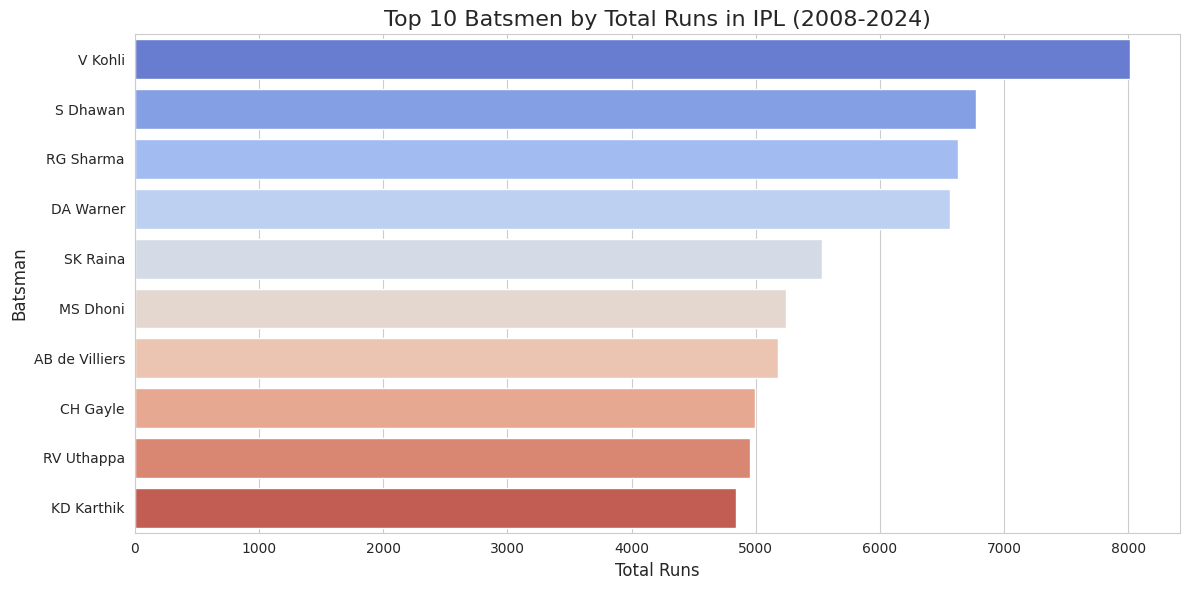

Observations: Virat Kohli leads as the highest run scorer in IPL history.


In [95]:
# Analysis4 - Top 10 Batsmen by Runs
plt.figure(figsize=(12,6))

top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='coolwarm')
plt.title('Top 10 Batsmen by Total Runs in IPL (2008-2024)', fontsize=16)
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.savefig('analysis4_top_batsmen.png')
plt.show()

print("Observations: Virat Kohli leads as the highest run scorer in IPL history.")

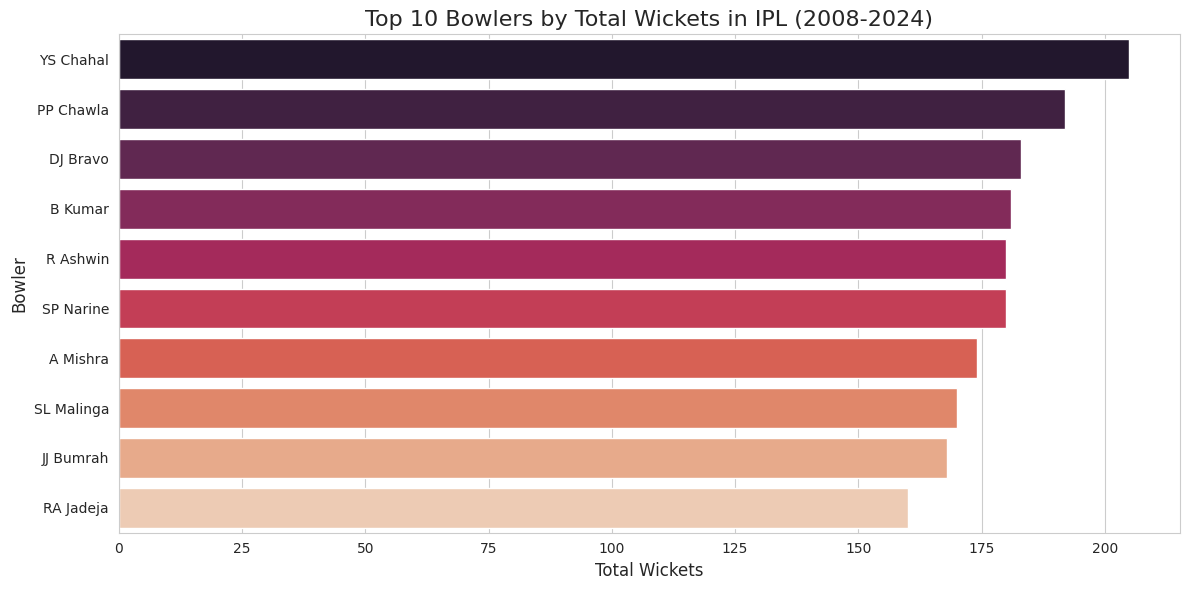

Observation: YS Chahal and PP Chawla are among the top wicket takers.


In [96]:
# Analysis 5 - Top 10 Bowlers by Wickets
plt.figure(figsize=(12,6))

# filter only bowler wickets
bowler_wickets = deliveries[deliveries['is_wicket'] == 1]
bowler_wickets = bowler_wickets[~bowler_wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = bowler_wickets.groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)

sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='rocket')
plt.title('Top 10 Bowlers by Total Wickets in IPL (2008-2024)', fontsize=16)
plt.xlabel('Total Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.tight_layout()
plt.savefig('analysis5_top_bowlers.png')
plt.show()

print("Observation: YS Chahal and PP Chawla are among the top wicket takers.")


In [97]:
# see all exact team names
print(matches['winner'].unique())

['Kolkata Knight Riders' 'Chennai Super Kings' 'Delhi Daredevils'
 'Royal Challengers Bangalore' 'Rajasthan Royals' 'Kings XI Punjab'
 'Deccan Chargers' 'Mumbai Indians' 'Pune Warriors' 'Kochi Tuskers Kerala'
 nan 'Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Royal Challengers Bengaluru']


Empty DataFrame
Columns: [season, wins]
Index: []


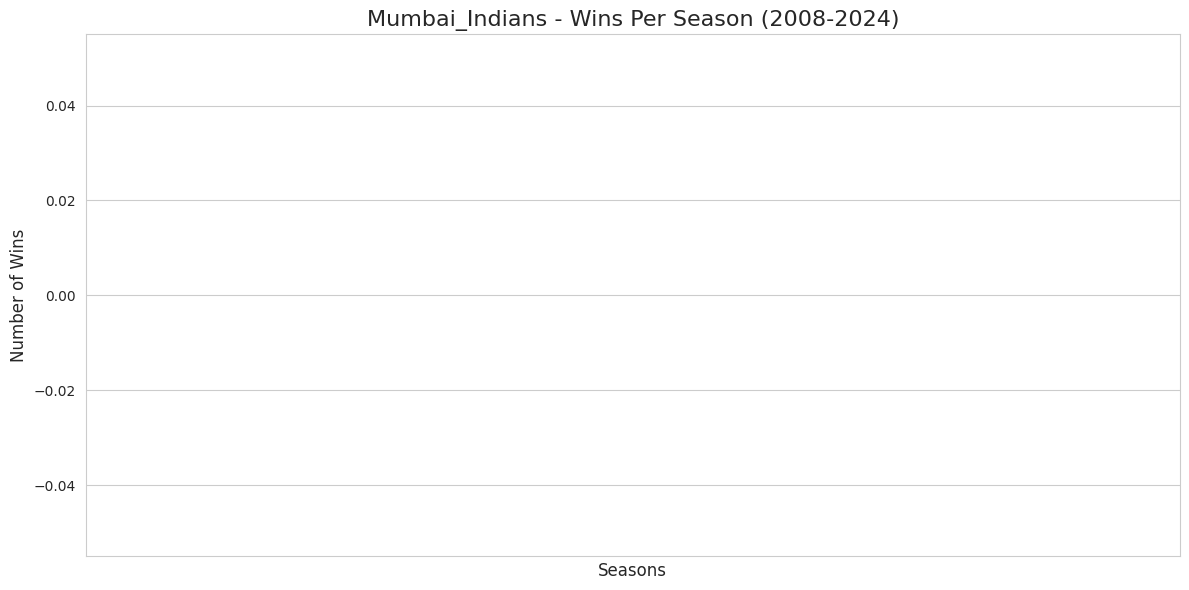

In [99]:
# Analysis6 - Wins Per Season for Your Team
# fix season column and plot
plt.figure(figsize=(12,6))

# Change to your favourite team
my_team = 'Mumbai_Indians'

# Get wins per season for your team
season_wins = matches[matches['winner'] == my_team].groupby('season')['winner'].count().reset_index()
season_wins.columns = ['season', 'wins']

print(season_wins)

# Fixed plot code
plt.plot(range(len(season_wins)), season_wins['wins'], marker='o', color='blue', linewidth=2, markersize=8)
plt.xticks(range(len(season_wins)), season_wins['season'], rotation=45)
plt.title(f'{my_team} - Wins Per Season (2008-2024)', fontsize=16)
plt.xlabel('Seasons', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.tight_layout()
plt.savefig('analysis6_team_season_wins.png')
plt.show()


Empty DataFrame
Columns: [season, wins]
Index: []


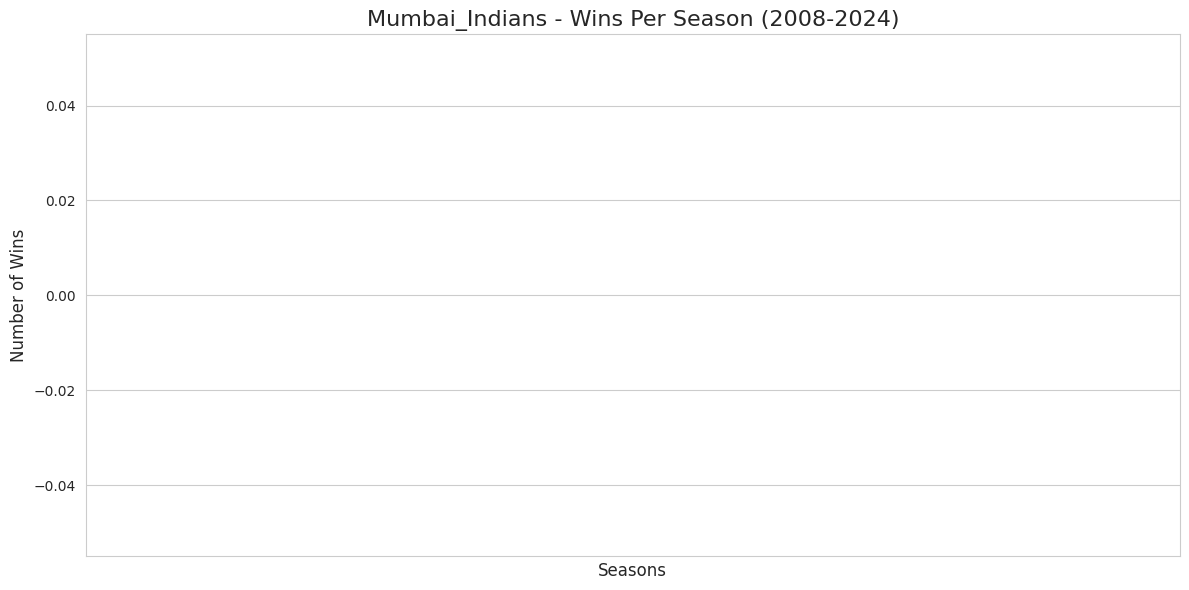

In [100]:
# Analysis6 - Wins Per Season for Your Team
# Reload fresh first
matches = pd.read_csv('matches.csv')

# Clean winner column
matches['winner'].fillna('No Result', inplace=True)

# Now plot
plt.figure(figsize=(12,6))

# Change to your favourite team
my_team = 'Mumbai_Indians'

# Get wins per season for your team
season_wins = matches[matches['winner'] == my_team].groupby('season')['winner'].count().reset_index()
season_wins.columns = ['season', 'wins']

print(season_wins)

# Fixed plot code
plt.plot(range(len(season_wins)), season_wins['wins'], marker='o', color='blue', linewidth=2, markersize=8)
plt.xticks(range(len(season_wins)), season_wins['season'], rotation=45)
plt.title(f'{my_team} - Wins Per Season (2008-2024)', fontsize=16)
plt.xlabel('Seasons', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.tight_layout()
plt.show()

In [101]:
# Analysis6 - Wins Per Season for Your Team
# Check exactly what is in winner column right now
print(type(matches))
print(matches.shape)
print(matches['winner'].value_counts().head(10))

<class 'pandas.core.frame.DataFrame'>
(1095, 20)
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


Team name: 'Mumbai Indians'
     season  wins
0   2007/08     7
1      2009     5
2   2009/10    11
3      2011    10
4      2012    10
5      2013    13
6      2014     7
7      2015    10
8      2016     7
9      2017    12
10     2018     6
11     2019    11
12  2020/21    11
13     2021     7
14     2022     4
15     2023     9
16     2024     4


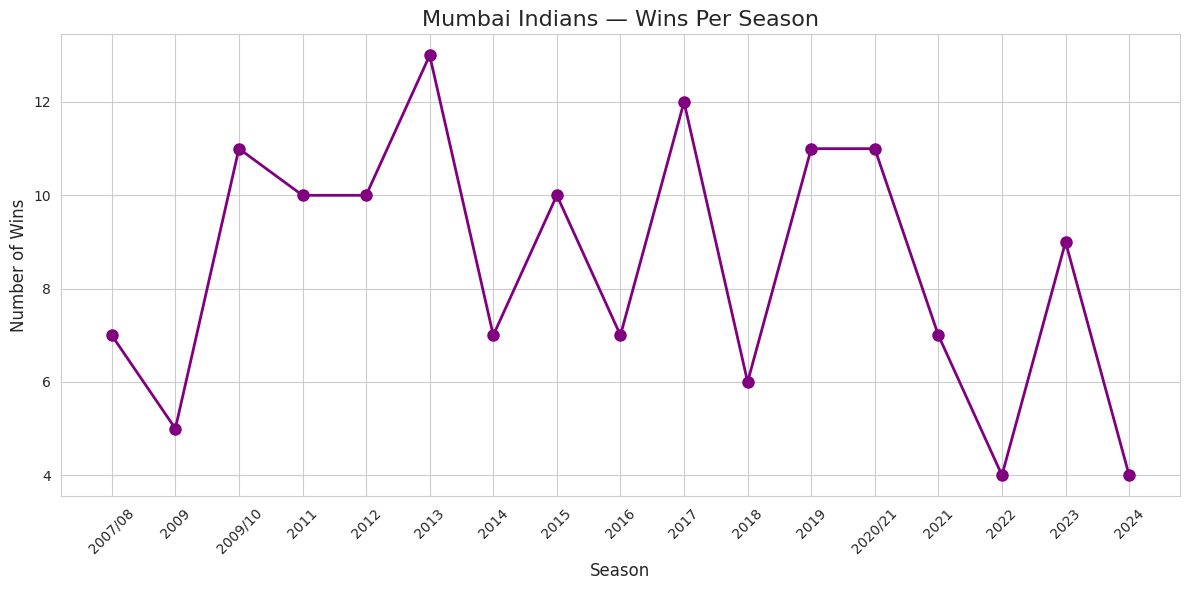

In [103]:
# Extract team name directly from data itself
my_team = matches['winner'].value_counts().index[0]
print(f"Team name: '{my_team}'")

# Now plot
plt.figure(figsize=(12,6))

season_wins = matches[matches['winner'] == my_team].groupby('season')['winner'].count().reset_index()
season_wins.columns = ['season', 'wins']

print(season_wins)

plt.plot(range(len(season_wins)), season_wins['wins'],
         marker='o', color='purple', linewidth=2, markersize=8)

plt.xticks(range(len(season_wins)), season_wins['season'], rotation=45)
plt.title(f'{my_team} — Wins Per Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.tight_layout()
plt.savefig('analysis6_wins_per_season.png')
plt.show()

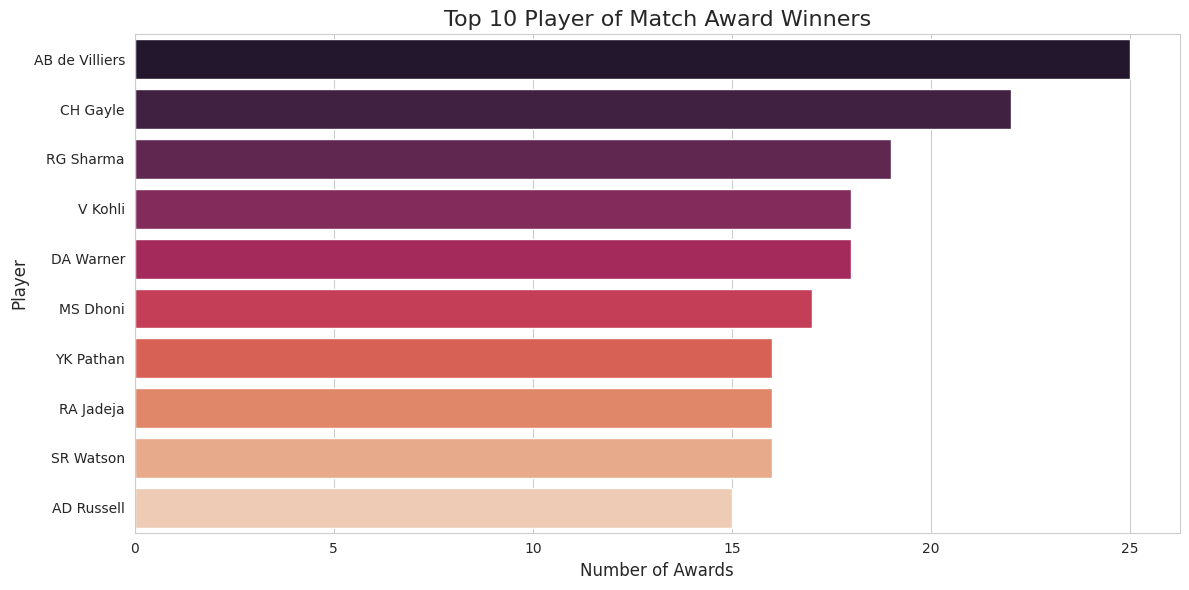

Observation: AB de Villiers and Chris Gayle dominate player of match awards


In [104]:
# Analysis7 - Player of the Match Awards
plt.figure(figsize=(12,6))

top_pom = matches['player_of_match'].value_counts().head(10)

sns.barplot(x=top_pom.values, y=top_pom.index, palette='rocket')
plt.title('Top 10 Player of Match Award Winners', fontsize=16)
plt.xlabel('Number of Awards', fontsize=12)
plt.ylabel('Player', fontsize=12)
plt.tight_layout()
plt.savefig('analysis7_player_of_match.png')
plt.show()

print("Observation: AB de Villiers and Chris Gayle dominate player of match awards")

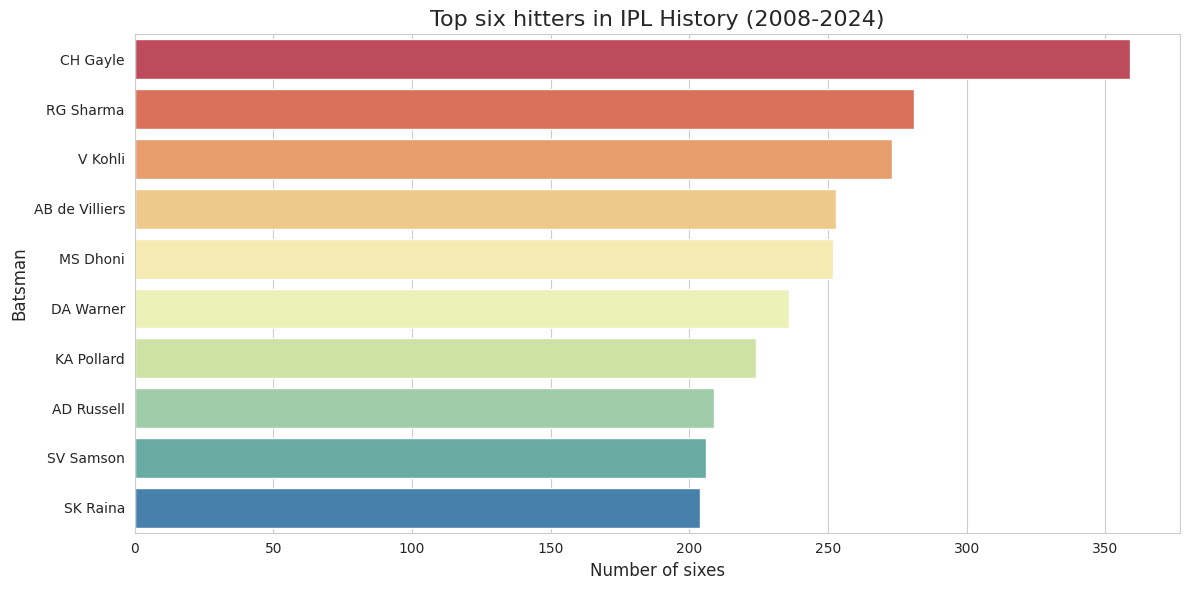

Observation: Chris Gayle is the biggest six hitter in the IPL history


In [105]:
# Analysis 8 - Most Sixes by Batsmen
plt.figure(figsize=(12,6))

sixes = deliveries[deliveries['batsman_runs'] == 6]
top_six_hitters = sixes.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)

sns.barplot(x=top_six_hitters.values, y=top_six_hitters.index, palette='Spectral')
plt.title('Top six hitters in IPL History (2008-2024)', fontsize=16)
plt.xlabel('Number of sixes', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.savefig('analysis8_top_six_hitter.png')
plt.show()

print("Observation: Chris Gayle is the biggest six hitter in the IPL history")

In [106]:
print("=" * 50)
print("IPL DATA ANALYSIS - KEY SUMMARY")
print("=" * 50)
print(f"Total Matches Analyzed: {len(matches)}")
print(f"Total Seasons: {matches['season'].nunique()}")
print(f"Total Teams: {matches['team1'].nunique()}")
print(f"Total Deliveries: {len(deliveries)}")
print()
print("Top Findings:")
print("1. Mumbai Indians have the most wins in IPL History")
print("2. Teams prefer to field after winning toss")
print(f"3. Toss winners won {percentage}% of matches")
print("4. Virat Kohli is the highest run scorer")
print("5. Chris Gayle is the biggest six hitter")
print("=" * 50)


IPL DATA ANALYSIS - KEY SUMMARY
Total Matches Analyzed: 1095
Total Seasons: 17
Total Teams: 19
Total Deliveries: 260920

Top Findings:
1. Mumbai Indians have the most wins in IPL History
2. Teams prefer to field after winning toss
3. Toss winners won 50.59% of matches
4. Virat Kohli is the highest run scorer
5. Chris Gayle is the biggest six hitter
